# Reproducible Research: Bacterial Growth Analysis


This notebook runs the analysis using data hosted on Google Drive.
**Instructions:** Just run the cells in order. No manual uploads required.

## Clone Code & Download Data

In [1]:
import os
import gdown
import zipfile

# --- 1. Clone the Code ---
repo_url = "https://github.com/junming732/bacterial_flow_analysis.git"
repo_name = "bacterial_flow_analysis"

if not os.path.exists(repo_name):
    print(f"Cloning {repo_url}...")
    !git clone $repo_url
else:
    print("Repository already cloned!")

os.chdir(repo_name)

# --- 2. Install Dependencies ---
print("Installing dependencies...")
!pip install -r requirements.txt -q

# --- 3. Download Data from Google Drive ---
file_id = '1n7r0TTe6ZPlWk-i4R6Mspw55LQX8Gl0m'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'data.zip'

if not os.path.exists('data'):
    print(f"Downloading data.zip from Google Drive...")
    gdown.download(url, output, quiet=False)

    print("Extracting data...")
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall('data')
    print("Data ready in ./data/")
else:
    print("Data folder already exists.")

Cloning https://github.com/junming732/bacterial_flow_analysis.git...
Cloning into 'bacterial_flow_analysis'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (67/67), done.
Receiving objects: 100% (77/77), 10.82 MiB | 20.60 MiB/s, done.
remote: Total 77 (delta 15), reused 69 (delta 7), pack-reused 0 (from 0)
Resolving deltas: 100% (15/15), done.
Installing dependencies...


Downloading...
From (original): https://drive.google.com/uc?id=1n7r0TTe6ZPlWk-i4R6Mspw55LQX8Gl0m
From (redirected): https://drive.google.com/uc?id=1n7r0TTe6ZPlWk-i4R6Mspw55LQX8Gl0m&confirm=t&uuid=d402fb86-174f-4dc6-ac97-8b6b3f428d2c
To: /content/bacterial_flow_analysis/data.zip
100%|██████████| 1.63G/1.63G [00:18<00:00, 89.8MB/s]


Extracting data...
✅ Data ready in ./data/


## Run Analysis

In [2]:
# Run Quantitative Analysis
print("--- Running Quantitative Analysis ---")
!python analysis_comparison.py

# Run Visualization
print("\n--- Running Qualitative Visualization ---")
!python vector_viz.py

--- Running Quantitative Analysis ---
REF vs RIF10 COMPARISON ANALYSIS
  Processing REF Pos101 (121 frames)...
  Processing REF Pos102 (121 frames)...
  Processing REF Pos103 (121 frames)...
  Processing REF Pos104 (121 frames)...
  Processing REF Pos105 (121 frames)...
  Processing REF Pos106 (121 frames)...
  Processing REF Pos107 (121 frames)...
  Processing REF Pos108 (121 frames)...
  Processing REF Pos109 (121 frames)...
  Processing REF Pos110 (121 frames)...
  Processing RIF10 Pos201 (121 frames)...
  Processing RIF10 Pos202 (121 frames)...
  Processing RIF10 Pos203 (121 frames)...
  Processing RIF10 Pos204 (121 frames)...
  Processing RIF10 Pos205 (121 frames)...
  Processing RIF10 Pos206 (121 frames)...
  Processing RIF10 Pos207 (121 frames)...
  Processing RIF10 Pos208 (121 frames)...
  Processing RIF10 Pos209 (121 frames)...
  Processing RIF10 Pos210 (121 frames)...
Comparison plot saved to results_comparison.png
CSV data saved.

--- Running Qualitative Visualization ---
Ge

## View Results

--- Comparison Plot ---


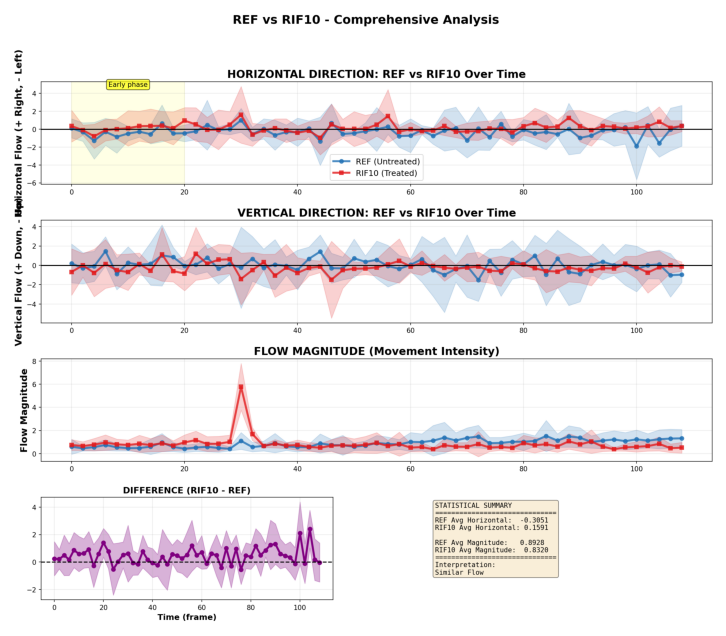


--- Sample Visualization ---


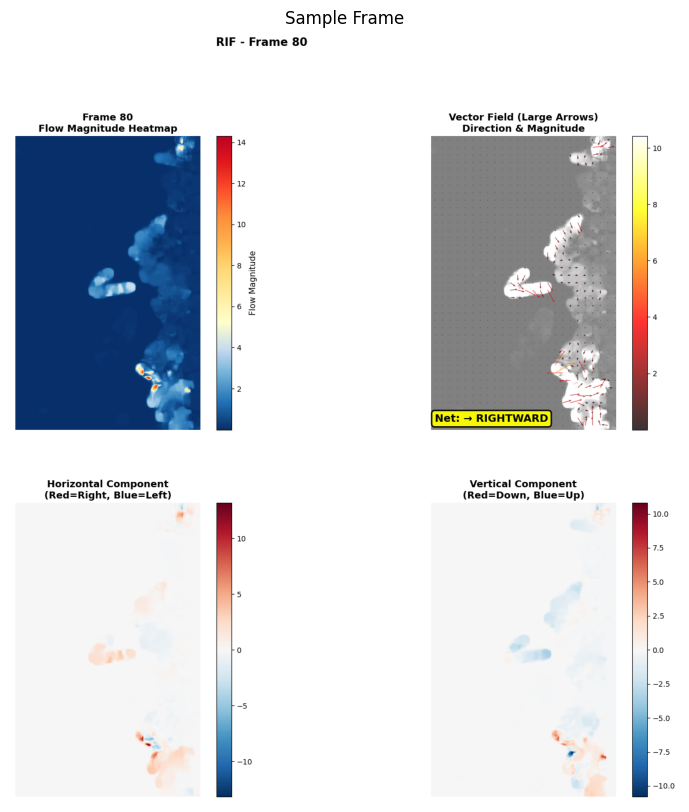

In [3]:
import matplotlib.pyplot as plt
import cv2
import glob

# Show Comparison Plot
print("--- Comparison Plot ---")
possible_paths = [
    "results_comparison.png",
    "ref_vs_rif10_comparison/REF_vs_RIF10_timeseries_comparison.png"
]
for p in possible_paths:
    if os.path.exists(p):
        img = cv2.imread(p)
        plt.figure(figsize=(12,8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
        break

# Show Sample Visualization
print("\n--- Sample Visualization ---")
viz_files = glob.glob("results_viz/*.png") + glob.glob("viz_result/*.png")
if viz_files:
    img = cv2.imread(viz_files[len(viz_files)//2])
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Sample Frame")
    plt.show()